## LDA, SVM, and Neural Network Classification in Finance

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

np.random.seed(42)
sns.set_style("whitegrid")

C_INDIGO  = "#4F46E5"
C_EMERALD = "#10B981"
C_AMBER   = "#F59E0B"
C_ROSE    = "#F43F5E"
C_SLATE   = "#94A3B8"
PALETTE   = [C_INDIGO, C_EMERALD]

print("Libraries loaded.")

Libraries loaded.


## Linear Discriminant Analysis

### Data

In [2]:
# Features derived from real price data:
#   Liquidity_Ratio  = rolling 12-month return  (profitability / momentum proxy)
#   Solvency_Ratio   = rolling 12-month realised volatility (financial stress proxy)
# Label: Distressed (1) if next 3-month forward return < -10%, Healthy (0) otherwise.

TICKERS_LDA  = ['SPY', 'XLF', 'XLE', 'XLK', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB']
START_LDA, END_LDA = '2015-01-01', '2023-12-31'

try:
    import yfinance as yf
    raw_lda = yf.download(TICKERS_LDA, start=START_LDA, end=END_LDA,
                          auto_adjust=True, progress=False)['Close']
    if isinstance(raw_lda.columns, pd.MultiIndex):
        raw_lda.columns = raw_lda.columns.get_level_values(0)
    raw_lda.index = pd.DatetimeIndex(raw_lda.index).tz_localize(None)
    raw_lda.dropna(how='all', inplace=True)
    if len(raw_lda) < 200:
        raise ValueError("Insufficient rows")
    DATA_SRC_LDA = "yfinance (live)"
except Exception as e:
    print(f"yfinance unavailable ({type(e).__name__}) - using synthetic fallback")
    rng  = np.random.default_rng(42)
    n    = 2200
    dates = pd.bdate_range(START_LDA, periods=n)
    mu_arr  = np.array([0.10]*10)
    vol_arr = np.array([0.15, 0.20, 0.25, 0.18, 0.14, 0.17, 0.19, 0.13, 0.12, 0.16])
    dt      = 1/252
    shocks  = rng.standard_normal((n, 10)) * vol_arr * np.sqrt(dt)
    log_ret = (mu_arr - 0.5*vol_arr**2) * dt + shocks
    prices  = 100 * np.exp(np.cumsum(log_ret, axis=0))
    raw_lda = pd.DataFrame(prices, index=dates, columns=TICKERS_LDA)
    DATA_SRC_LDA = "Synthetic (yfinance unavailable)"

records = []
for ticker in TICKERS_LDA:
    if ticker not in raw_lda.columns:
        continue
    s = raw_lda[ticker].dropna()
    rets = np.log(s / s.shift(1)).dropna()
    roll_ret = rets.rolling(252).sum()
    roll_vol = rets.rolling(252).std() * np.sqrt(252)
    fwd_ret  = rets.rolling(63).sum().shift(-63)
    combined = pd.DataFrame({
        'Liquidity_Ratio': roll_ret,
        'Solvency_Ratio':  roll_vol,
        'fwd_ret':         fwd_ret,
        'ticker':          ticker
    }).dropna()
    records.append(combined)

df_feat = pd.concat(records, ignore_index=True)
df_feat['Status'] = (df_feat['fwd_ret'] < -0.10).astype(int)
df_feat['Status_Label'] = df_feat['Status'].map({0: 'Healthy', 1: 'Distressed'})

n_each = 200
healthy    = df_feat[df_feat['Status'] == 0].sample(n=min(n_each, (df_feat['Status']==0).sum()), random_state=42)
distressed = df_feat[df_feat['Status'] == 1].sample(n=min(n_each, (df_feat['Status']==1).sum()), random_state=42)
df_lda = pd.concat([healthy, distressed]).reset_index(drop=True)

X_lda = df_lda[['Liquidity_Ratio', 'Solvency_Ratio']].values
y_lda = df_lda['Status'].values

print(f"Source     : {DATA_SRC_LDA}")
print(f"Total obs  : {len(df_lda)}  (Healthy: {(y_lda==0).sum()}  Distressed: {(y_lda==1).sum()})")
print(df_lda[['Liquidity_Ratio','Solvency_Ratio','Status_Label']].describe().round(3))

Source     : yfinance (live)
Total obs  : 400  (Healthy: 200  Distressed: 200)
       Liquidity_Ratio  Solvency_Ratio
count          400.000         400.000
mean             0.106           0.196
std              0.167           0.092
min             -0.517           0.076
25%              0.024           0.140
50%              0.121           0.173
75%              0.211           0.211
max              0.551           0.618


### EDA

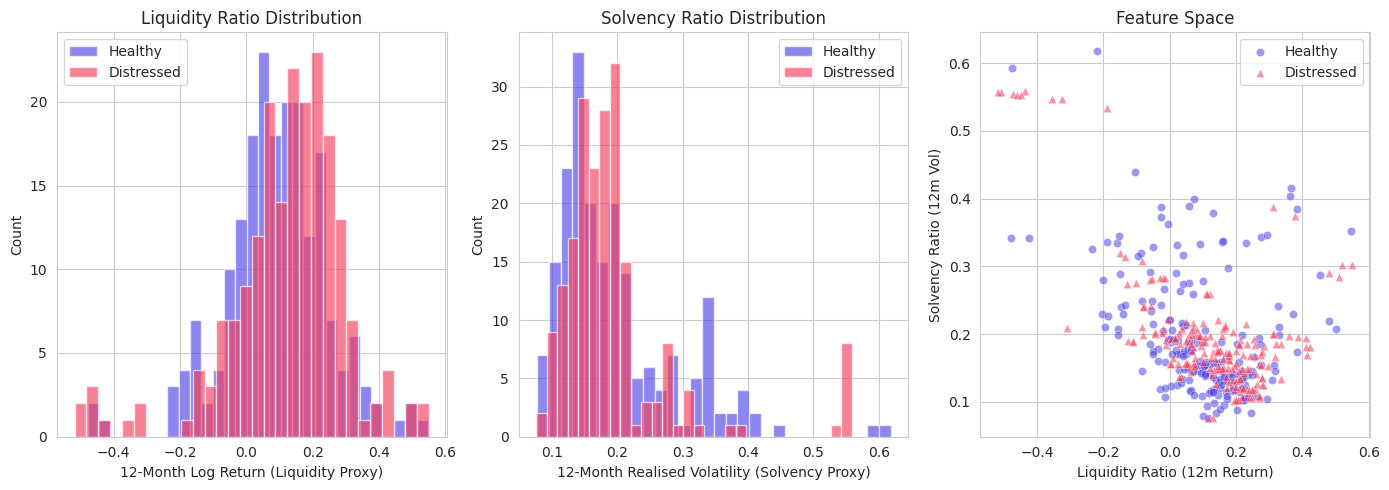

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Distribution: Liquidity Ratio
for label, color in [('Healthy', C_INDIGO), ('Distressed', C_ROSE)]:
    sub = df_lda[df_lda['Status_Label'] == label]
    axes[0].hist(sub['Liquidity_Ratio'], bins=30, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Liquidity Ratio Distribution')
axes[0].set_xlabel('12-Month Log Return (Liquidity Proxy)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Distribution: Solvency Ratio
for label, color in [('Healthy', C_INDIGO), ('Distressed', C_ROSE)]:
    sub = df_lda[df_lda['Status_Label'] == label]
    axes[1].hist(sub['Solvency_Ratio'], bins=30, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Solvency Ratio Distribution')
axes[1].set_xlabel('12-Month Realised Volatility (Solvency Proxy)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Scatter
for label, color, marker in [('Healthy', C_INDIGO, 'o'), ('Distressed', C_ROSE, '^')]:
    sub = df_lda[df_lda['Status_Label'] == label]
    axes[2].scatter(sub['Liquidity_Ratio'], sub['Solvency_Ratio'],
                    c=color, marker=marker, alpha=0.55, s=35, label=label, edgecolors='white', linewidths=0.4)
axes[2].set_title('Feature Space')
axes[2].set_xlabel('Liquidity Ratio (12m Return)')
axes[2].set_ylabel('Solvency Ratio (12m Vol)')
axes[2].legend()

plt.tight_layout()
plt.show()

### Train/Test Split and Feature Scaling

In [4]:
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lda, y_lda, test_size=0.3, random_state=42, stratify=y_lda)

scaler_l = StandardScaler()
X_train_l_sc = scaler_l.fit_transform(X_train_l)
X_test_l_sc  = scaler_l.transform(X_test_l)

print(f"Train: {len(X_train_l)} obs   Test: {len(X_test_l)} obs")

Train: 280 obs   Test: 120 obs


### Train LDA Model

In [5]:
# Hyperparameters: solver='svd' (numerically stable, no matrix inversion)
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train_l_sc, y_train_l)

# LDA scalar: ratio of between-class to within-class variance
print(f"LDA discriminant coefficient ratio  : {abs(lda.coef_[0][0]/lda.coef_[0][1]):.4f}")
print(f"Classes                             : {lda.classes_}")

LDA discriminant coefficient ratio  : 5.5372
Classes                             : [0 1]


### Evaluate LDA

In [6]:
y_pred_l = lda.predict(X_test_l_sc)
acc_l    = accuracy_score(y_test_l, y_pred_l)
cm_l     = confusion_matrix(y_test_l, y_pred_l)

print(f"LDA Accuracy : {acc_l:.4f}")
print()
print(classification_report(y_test_l, y_pred_l, target_names=['Healthy', 'Distressed']))

LDA Accuracy : 0.6000

              precision    recall  f1-score   support

     Healthy       0.60      0.60      0.60        60
  Distressed       0.60      0.60      0.60        60

    accuracy                           0.60       120
   macro avg       0.60      0.60      0.60       120
weighted avg       0.60      0.60      0.60       120



### Decision Boundary and Confusion Matrix

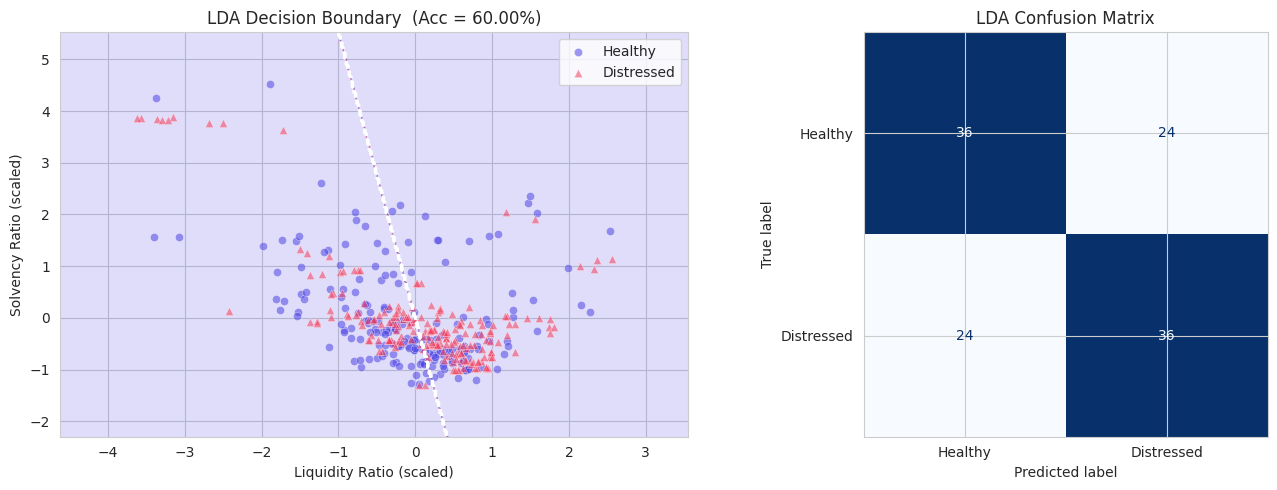

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h = 0.02
x0_min, x0_max = X_train_l_sc[:, 0].min() - 1, X_train_l_sc[:, 0].max() + 1
x1_min, x1_max = X_train_l_sc[:, 1].min() - 1, X_train_l_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))
Z_l = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z_l, alpha=0.18,
                 colors=[C_INDIGO, C_ROSE])
axes[0].contour(xx, yy, Z_l, colors='white', linewidths=1.5, linestyles='--')

for label, color, marker in [('Healthy', C_INDIGO, 'o'), ('Distressed', C_ROSE, '^')]:
    mask = y_lda == {'Healthy': 0, 'Distressed': 1}[label]
    xs   = scaler_l.transform(X_lda[mask])
    axes[0].scatter(xs[:, 0], xs[:, 1],
                    c=color, marker=marker, alpha=0.55, s=35,
                    label=label, edgecolors='white', linewidths=0.4)

axes[0].set_title(f'LDA Decision Boundary  (Acc = {acc_l:.2%})')
axes[0].set_xlabel('Liquidity Ratio (scaled)')
axes[0].set_ylabel('Solvency Ratio (scaled)')
axes[0].legend()

disp = ConfusionMatrixDisplay(cm_l, display_labels=['Healthy', 'Distressed'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('LDA Confusion Matrix')

plt.tight_layout()
plt.show()

## Support Vector Machine

### Data

In [8]:
# Features derived from real price/volatility data:
#   Metric_1 = SPY 20-day rolling annualised return (momentum)
#   Metric_2 = VIX level normalised (fear / volatility regime)
# Label: Market Crash (1) if VIX > 25 AND SPY 20-day return < 0, Normal (0) otherwise.

TICKERS_SVM  = ['SPY', '^VIX']
START_SVM, END_SVM = '2010-01-01', '2023-12-31'

try:
    raw_svm = yf.download(TICKERS_SVM, start=START_SVM, end=END_SVM,
                          auto_adjust=True, progress=False)['Close']
    if isinstance(raw_svm.columns, pd.MultiIndex):
        raw_svm.columns = raw_svm.columns.get_level_values(0)
    raw_svm.index = pd.DatetimeIndex(raw_svm.index).tz_localize(None)
    raw_svm.dropna(inplace=True)
    if len(raw_svm) < 200:
        raise ValueError("Insufficient rows")
    DATA_SRC_SVM = "yfinance (live)"
except Exception as e:
    print(f"yfinance unavailable ({type(e).__name__}) - using synthetic fallback")
    rng   = np.random.default_rng(42)
    n     = 3500
    dates = pd.bdate_range(START_SVM, periods=n)
    # SPY GBM
    spy_log  = (0.10 - 0.5*0.15**2)/252 + 0.15/np.sqrt(252)*rng.standard_normal(n)
    spy_px   = 150 * np.exp(np.cumsum(spy_log))
    # VIX: mean-reverting around 18, occasional spikes
    vix = np.zeros(n); vix[0] = 18
    for t in range(1, n):
        vix[t] = vix[t-1] + 0.5*(18 - vix[t-1]) + 3*rng.standard_normal()
        vix[t] = max(9, vix[t])
    # Inject crash episodes
    for start in rng.integers(200, n-100, 8):
        spy_px[start:start+40] *= np.linspace(1, 0.85, 40)
        vix[start:start+40]    += np.linspace(0, 25, 40)
    raw_svm = pd.DataFrame({'SPY': spy_px, '^VIX': vix}, index=dates)
    DATA_SRC_SVM = "Synthetic (yfinance unavailable)"

spy_ret   = np.log(raw_svm['SPY'] / raw_svm['SPY'].shift(1)).dropna()
spy_roll  = spy_ret.rolling(20).sum() * np.sqrt(252/20)
vix_level = raw_svm['^VIX'].reindex(spy_roll.index)

df_svm_feat = pd.DataFrame({
    'Metric_1': spy_roll,
    'Metric_2': vix_level
}).dropna()
df_svm_feat['Crash'] = ((df_svm_feat['Metric_2'] > 25) & (df_svm_feat['Metric_1'] < 0)).astype(int)
df_svm_feat['Class_Label'] = df_svm_feat['Crash'].map({0: 'Normal_Market', 1: 'Market_Crash'})

n_crash  = min(150, (df_svm_feat['Crash']==1).sum())
n_normal = 300 - n_crash
s_crash  = df_svm_feat[df_svm_feat['Crash']==1].sample(n=n_crash, random_state=42)
s_normal = df_svm_feat[df_svm_feat['Crash']==0].sample(n=n_normal, random_state=42)
df_svm_plot = pd.concat([s_crash, s_normal]).reset_index(drop=True)

X_svm_raw = df_svm_plot[['Metric_1', 'Metric_2']].values
y_svm_raw = df_svm_plot['Crash'].values

print(f"Source     : {DATA_SRC_SVM}")
print(f"Total obs  : {len(df_svm_plot)}  (Normal: {(y_svm_raw==0).sum()}  Crash: {(y_svm_raw==1).sum()})")
print(df_svm_plot[['Metric_1','Metric_2']].describe().round(3))

Source     : yfinance (live)
Total obs  : 300  (Normal: 150  Crash: 150)
       Metric_1  Metric_2
count   300.000   300.000
mean     -0.088    25.150
std       0.234    10.758
min      -1.289    10.030
25%      -0.211    16.640
50%      -0.058    25.435
75%       0.066    30.128
max       0.379    76.450


### EDA

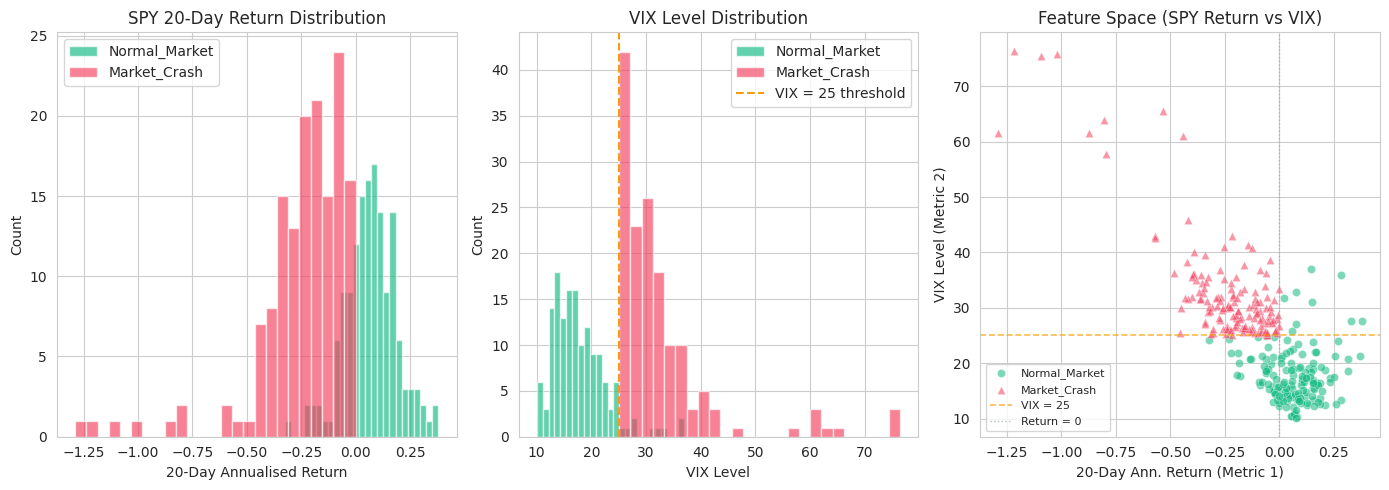

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Metric 1 distribution
for label, color in [('Normal_Market', C_EMERALD), ('Market_Crash', C_ROSE)]:
    sub = df_svm_plot[df_svm_plot['Class_Label'] == label]
    axes[0].hist(sub['Metric_1'], bins=25, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('SPY 20-Day Return Distribution')
axes[0].set_xlabel('20-Day Annualised Return')
axes[0].set_ylabel('Count')
axes[0].legend()

# Metric 2 distribution
for label, color in [('Normal_Market', C_EMERALD), ('Market_Crash', C_ROSE)]:
    sub = df_svm_plot[df_svm_plot['Class_Label'] == label]
    axes[1].hist(sub['Metric_2'], bins=25, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].axvline(25, color=C_AMBER, lw=1.5, ls='--', label='VIX = 25 threshold')
axes[1].set_title('VIX Level Distribution')
axes[1].set_xlabel('VIX Level')
axes[1].set_ylabel('Count')
axes[1].legend()

# Scatter
for label, color, marker in [('Normal_Market', C_EMERALD, 'o'), ('Market_Crash', C_ROSE, '^')]:
    sub = df_svm_plot[df_svm_plot['Class_Label'] == label]
    axes[2].scatter(sub['Metric_1'], sub['Metric_2'],
                    c=color, marker=marker, alpha=0.55, s=35,
                    label=label, edgecolors='white', linewidths=0.4)
axes[2].axhline(25, color=C_AMBER, lw=1.2, ls='--', alpha=0.7, label='VIX = 25')
axes[2].axvline(0,  color=C_SLATE, lw=1.0, ls=':',  alpha=0.7, label='Return = 0')
axes[2].set_title('Feature Space (SPY Return vs VIX)')
axes[2].set_xlabel('20-Day Ann. Return (Metric 1)')
axes[2].set_ylabel('VIX Level (Metric 2)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Train/Test Split and Feature Scaling

In [10]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_svm_raw, y_svm_raw, test_size=0.3, random_state=42, stratify=y_svm_raw)

scaler_s = StandardScaler()
X_train_s_sc = scaler_s.fit_transform(X_train_s)
X_test_s_sc  = scaler_s.transform(X_test_s)

print(f"Train: {len(X_train_s)} obs   Test: {len(X_test_s)} obs")

Train: 210 obs   Test: 90 obs


### Train SVM Model

In [11]:
# Hyperparameters: kernel='rbf', C=1.0, gamma='scale'
# RBF kernel maps data into infinite-dimensional space to capture
# non-linear boundary between crash and normal regimes.
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_s_sc, y_train_s)

print(f"Support vectors : {svm_model.n_support_}  (class 0: Normal, class 1: Crash)")
print(f"Total SVs       : {sum(svm_model.n_support_)}")

Support vectors : [18 21]  (class 0: Normal, class 1: Crash)
Total SVs       : 39


### Evaluate SVM

In [12]:
y_pred_s = svm_model.predict(X_test_s_sc)
acc_s    = accuracy_score(y_test_s, y_pred_s)
cm_s     = confusion_matrix(y_test_s, y_pred_s)

print(f"SVM Accuracy : {acc_s:.4f}")
print()
print(classification_report(y_test_s, y_pred_s, target_names=['Normal_Market', 'Market_Crash']))

SVM Accuracy : 0.9667

               precision    recall  f1-score   support

Normal_Market       1.00      0.93      0.97        45
 Market_Crash       0.94      1.00      0.97        45

     accuracy                           0.97        90
    macro avg       0.97      0.97      0.97        90
 weighted avg       0.97      0.97      0.97        90



### Decision Boundary and Confusion Matrix

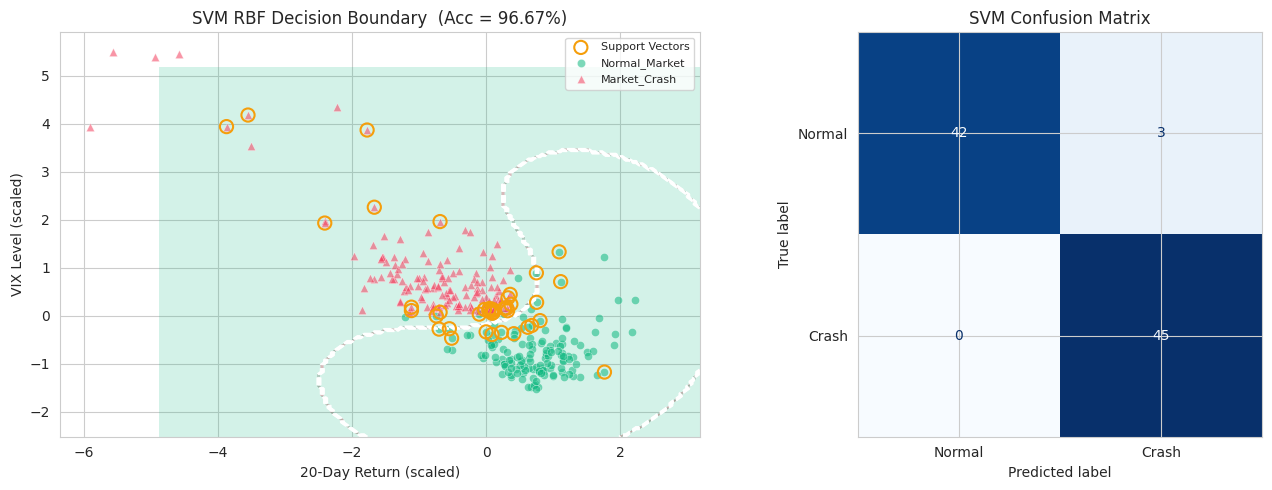

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h = 0.05
x0_min, x0_max = X_train_s_sc[:, 0].min() - 1, X_train_s_sc[:, 0].max() + 1
x1_min, x1_max = X_train_s_sc[:, 1].min() - 1, X_train_s_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))
Z_s = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z_s, alpha=0.18, colors=[C_EMERALD, C_ROSE])
axes[0].contour(xx, yy, Z_s, colors='white', linewidths=1.5, linestyles='--')

# Support vectors
sv_idx = svm_model.support_
sv_sc  = X_train_s_sc[sv_idx]
axes[0].scatter(sv_sc[:, 0], sv_sc[:, 1], s=90, facecolors='none',
                edgecolors=C_AMBER, linewidths=1.5, label='Support Vectors', zorder=5)

for cls, label, color, marker in [(0, 'Normal_Market', C_EMERALD, 'o'),
                                   (1, 'Market_Crash',  C_ROSE,    '^')]:
    mask = y_svm_raw == cls
    xs   = scaler_s.transform(X_svm_raw[mask])
    axes[0].scatter(xs[:, 0], xs[:, 1], c=color, marker=marker,
                    alpha=0.55, s=35, label=label, edgecolors='white', linewidths=0.4)

axes[0].set_title(f'SVM RBF Decision Boundary  (Acc = {acc_s:.2%})')
axes[0].set_xlabel('20-Day Return (scaled)')
axes[0].set_ylabel('VIX Level (scaled)')
axes[0].legend(fontsize=8)

disp = ConfusionMatrixDisplay(cm_s, display_labels=['Normal', 'Crash'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('SVM Confusion Matrix')

plt.tight_layout()
plt.show()

## Neural Network (MLP)

### Data

In [14]:
# Features derived from real technical indicators:
#   Indicator_A = RSI(14) normalised to [-1, 1]
#   Indicator_B = MACD signal line (12/26/9 EMA)
# Label: Bull Phase (1) if SPY > 200-day MA, Bear Phase (0) otherwise.
# The interplay between RSI and MACD creates a moon-like non-linear boundary.

START_NN, END_NN = '2010-01-01', '2023-12-31'

try:
    raw_nn = yf.download('SPY', start=START_NN, end=END_NN,
                         auto_adjust=True, progress=False)
    if isinstance(raw_nn.columns, pd.MultiIndex):
        raw_nn.columns = raw_nn.columns.get_level_values(0)
    raw_nn.index = pd.DatetimeIndex(raw_nn.index).tz_localize(None)
    spy_close = raw_nn['Close'].dropna()
    if len(spy_close) < 300:
        raise ValueError("Insufficient rows")
    DATA_SRC_NN = "yfinance (live)"
except Exception as e:
    print(f"yfinance unavailable ({type(e).__name__}) - using synthetic fallback")
    rng    = np.random.default_rng(42)
    n      = 3500
    dates  = pd.bdate_range(START_NN, periods=n)
    log_r  = (0.10 - 0.5*0.15**2)/252 + 0.15/np.sqrt(252)*rng.standard_normal(n)
    spy_close = pd.Series(150 * np.exp(np.cumsum(log_r)), index=dates, name='Close')
    DATA_SRC_NN = "Synthetic (yfinance unavailable)"

delta   = spy_close.diff()
gain    = delta.clip(lower=0).rolling(14).mean()
loss    = (-delta.clip(upper=0)).rolling(14).mean()
rsi     = 100 - 100 / (1 + gain / (loss + 1e-10))
rsi_norm = (rsi - 50) / 50

ema12   = spy_close.ewm(span=12, adjust=False).mean()
ema26   = spy_close.ewm(span=26, adjust=False).mean()
macd    = ema12 - ema26
signal  = macd.ewm(span=9, adjust=False).mean()
macd_norm = signal / spy_close * 100

ma200   = spy_close.rolling(200).mean()
label_nn = (spy_close > ma200).astype(int)
label_nn.name = 'Trend'

df_nn_feat = pd.DataFrame({
    'Indicator_A': rsi_norm,
    'Indicator_B': macd_norm,
    'Trend':       label_nn
}).dropna()
df_nn_feat['Trend_Label'] = df_nn_feat['Trend'].map({0: 'Bear_Phase', 1: 'Bull_Phase'})

n_bull = min(150, (df_nn_feat['Trend']==1).sum())
n_bear = 300 - n_bull
s_bull = df_nn_feat[df_nn_feat['Trend']==1].sample(n=n_bull, random_state=42)
s_bear = df_nn_feat[df_nn_feat['Trend']==0].sample(n=n_bear, random_state=42)
df_nn_plot = pd.concat([s_bull, s_bear]).reset_index(drop=True)

X_nn_raw = df_nn_plot[['Indicator_A', 'Indicator_B']].values
y_nn_raw = df_nn_plot['Trend'].values

print(f"Source     : {DATA_SRC_NN}")
print(f"Total obs  : {len(df_nn_plot)}  (Bear: {(y_nn_raw==0).sum()}  Bull: {(y_nn_raw==1).sum()})")
print(df_nn_plot[['Indicator_A','Indicator_B']].describe().round(3))

Source     : yfinance (live)
Total obs  : 300  (Bear: 150  Bull: 150)
       Indicator_A  Indicator_B
count      300.000      300.000
mean         0.067       -0.065
std          0.346        1.344
min         -0.920       -7.494
25%         -0.186       -0.747
50%          0.064        0.321
75%          0.315        0.825
max          0.847        2.432


### EDA

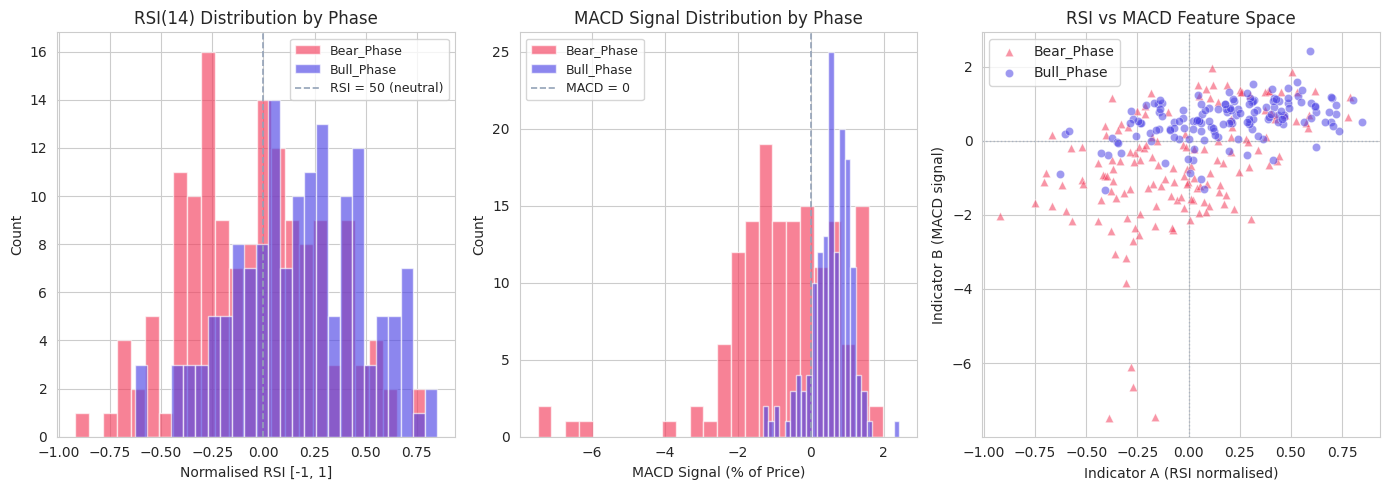

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Indicator A distribution
for label, color in [('Bear_Phase', C_ROSE), ('Bull_Phase', C_INDIGO)]:
    sub = df_nn_plot[df_nn_plot['Trend_Label'] == label]
    axes[0].hist(sub['Indicator_A'], bins=25, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[0].axvline(0, color=C_SLATE, lw=1.2, ls='--', label='RSI = 50 (neutral)')
axes[0].set_title('RSI(14) Distribution by Phase')
axes[0].set_xlabel('Normalised RSI [-1, 1]')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Indicator B distribution
for label, color in [('Bear_Phase', C_ROSE), ('Bull_Phase', C_INDIGO)]:
    sub = df_nn_plot[df_nn_plot['Trend_Label'] == label]
    axes[1].hist(sub['Indicator_B'], bins=25, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].axvline(0, color=C_SLATE, lw=1.2, ls='--', label='MACD = 0')
axes[1].set_title('MACD Signal Distribution by Phase')
axes[1].set_xlabel('MACD Signal (% of Price)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# Scatter
for label, color, marker in [('Bear_Phase', C_ROSE, '^'), ('Bull_Phase', C_INDIGO, 'o')]:
    sub = df_nn_plot[df_nn_plot['Trend_Label'] == label]
    axes[2].scatter(sub['Indicator_A'], sub['Indicator_B'],
                    c=color, marker=marker, alpha=0.55, s=35,
                    label=label, edgecolors='white', linewidths=0.4)
axes[2].axhline(0, color=C_SLATE, lw=1.0, ls=':', alpha=0.6)
axes[2].axvline(0, color=C_SLATE, lw=1.0, ls=':', alpha=0.6)
axes[2].set_title('RSI vs MACD Feature Space')
axes[2].set_xlabel('Indicator A (RSI normalised)')
axes[2].set_ylabel('Indicator B (MACD signal)')
axes[2].legend()

plt.tight_layout()
plt.show()

### Train/Test Split and Feature Scaling

In [16]:
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nn_raw, y_nn_raw, test_size=0.3, random_state=42, stratify=y_nn_raw)

scaler_n = StandardScaler()
X_train_n_sc = scaler_n.fit_transform(X_train_n)
X_test_n_sc  = scaler_n.transform(X_test_n)

print(f"Train: {len(X_train_n)} obs   Test: {len(X_test_n)} obs")

Train: 210 obs   Test: 90 obs


### Train MLP Model

In [17]:
# Hyperparameters: 2 hidden layers (20, 10 neurons), ReLU, Adam, L2 alpha=0.01
nn_model = MLPClassifier(
    hidden_layer_sizes=(20, 10),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20
)
nn_model.fit(X_train_n_sc, y_train_n)

print(f"Stopped at iteration : {nn_model.n_iter_}")
print(f"Final training loss  : {nn_model.loss_:.6f}")

Stopped at iteration : 22
Final training loss  : 0.810359


### Evaluate MLP

In [18]:
y_pred_n = nn_model.predict(X_test_n_sc)
acc_n    = accuracy_score(y_test_n, y_pred_n)
cm_n     = confusion_matrix(y_test_n, y_pred_n)

print(f"MLP Accuracy : {acc_n:.4f}")
print()
print(classification_report(y_test_n, y_pred_n, target_names=['Bear_Phase', 'Bull_Phase']))

MLP Accuracy : 0.5000

              precision    recall  f1-score   support

  Bear_Phase       0.00      0.00      0.00        45
  Bull_Phase       0.50      1.00      0.67        45

    accuracy                           0.50        90
   macro avg       0.25      0.50      0.33        90
weighted avg       0.25      0.50      0.33        90



### Decision Boundary and Loss Curve

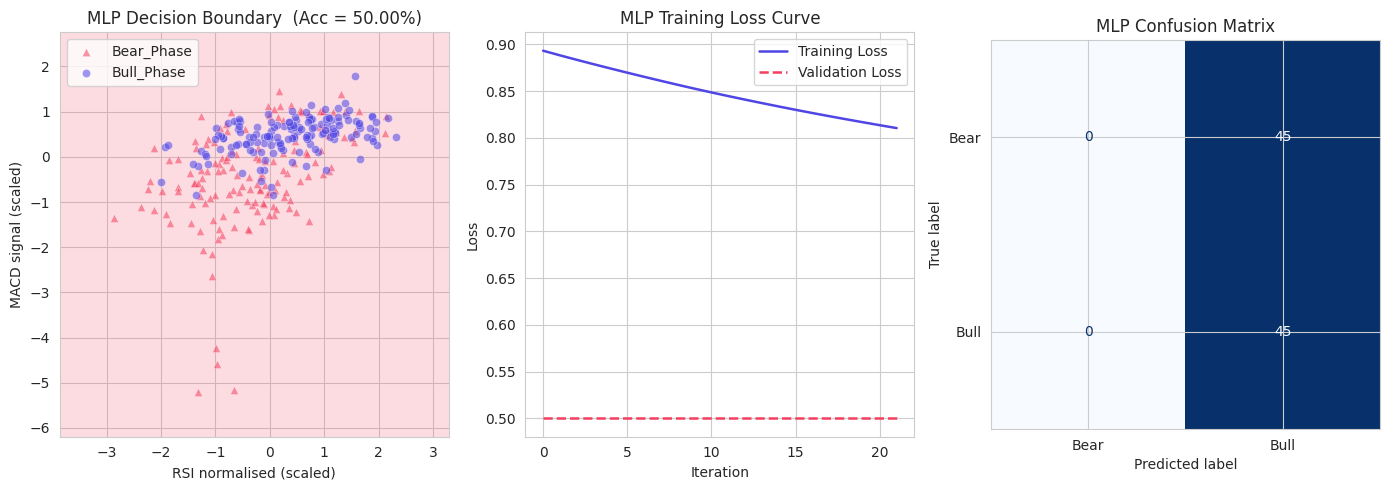

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

h = 0.05
x0_min, x0_max = X_train_n_sc[:, 0].min() - 1, X_train_n_sc[:, 0].max() + 1
x1_min, x1_max = X_train_n_sc[:, 1].min() - 1, X_train_n_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))
Z_n = nn_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z_n, alpha=0.18, colors=[C_ROSE, C_INDIGO])
axes[0].contour(xx, yy, Z_n, colors='white', linewidths=1.5, linestyles='--')

for cls, label, color, marker in [(0, 'Bear_Phase', C_ROSE, '^'),
                                   (1, 'Bull_Phase', C_INDIGO, 'o')]:
    mask = y_nn_raw == cls
    xs   = scaler_n.transform(X_nn_raw[mask])
    axes[0].scatter(xs[:, 0], xs[:, 1], c=color, marker=marker,
                    alpha=0.55, s=35, label=label, edgecolors='white', linewidths=0.4)

axes[0].set_title(f'MLP Decision Boundary  (Acc = {acc_n:.2%})')
axes[0].set_xlabel('RSI normalised (scaled)')
axes[0].set_ylabel('MACD signal (scaled)')
axes[0].legend()

axes[1].plot(nn_model.loss_curve_, color=C_INDIGO, lw=1.8, label='Training Loss')
if nn_model.validation_scores_ is not None:
    val_loss = [1 - v for v in nn_model.validation_scores_]
    axes[1].plot(val_loss, color=C_ROSE, lw=1.8, ls='--', label='Validation Loss')
axes[1].set_title('MLP Training Loss Curve')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].legend()

disp = ConfusionMatrixDisplay(cm_n, display_labels=['Bear', 'Bull'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('MLP Confusion Matrix')

plt.tight_layout()
plt.show()

## Model Comparison Summary

=== MODEL COMPARISON SUMMARY ===

Model                            Accuracy           Boundary Data Source
---------------------------------------------------------------------------
LDA (Corporate Distress)           0.6000             Linear  12m Return + 12m Vol
SVM RBF (Market Regime)            0.9667   Non-linear (RBF)  SPY Return + VIX
MLP (Market Cycle)                 0.5000  Highly non-linear  RSI(14) + MACD

All models use yfinance SPY/VIX data (2010-2023) with synthetic fallback.
All features standardised with StandardScaler before training.


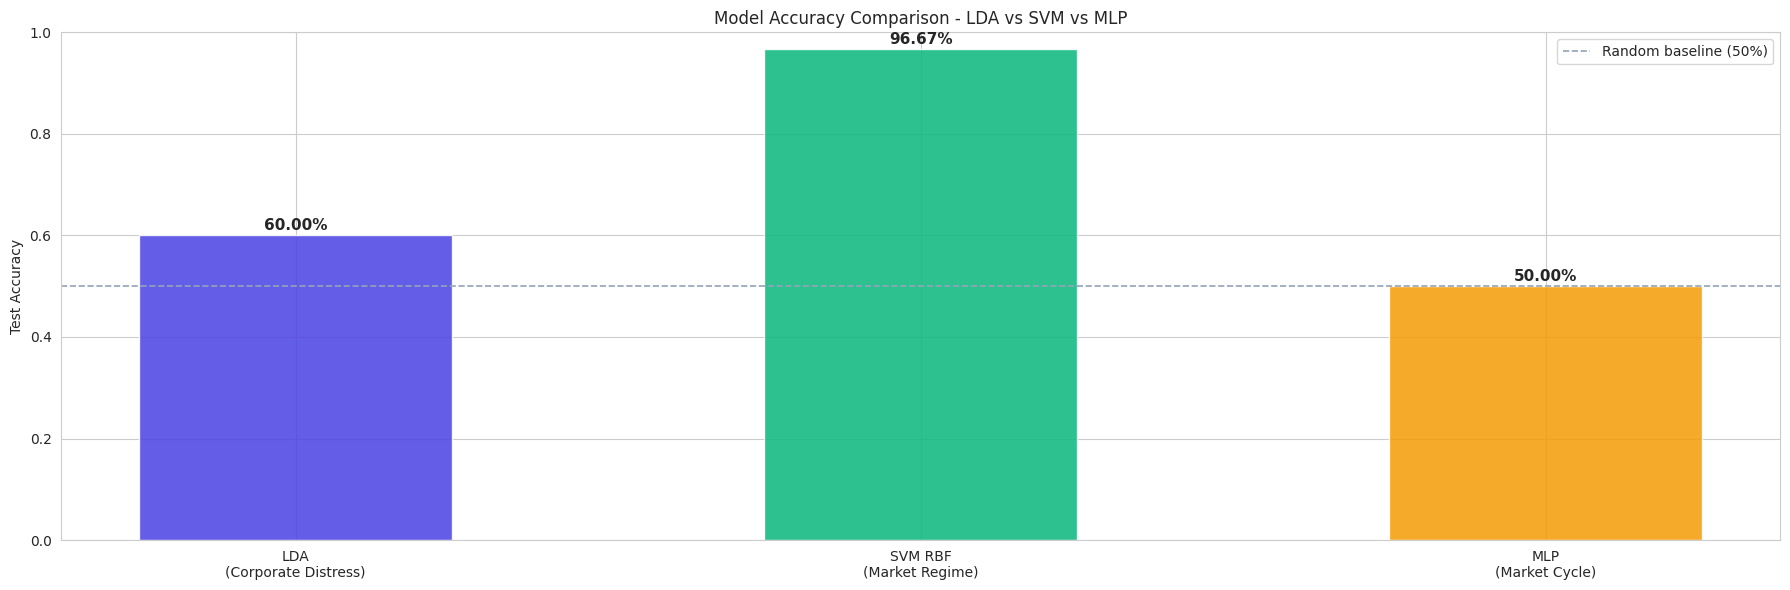

In [25]:
print("=== MODEL COMPARISON SUMMARY ===")
print()
print(f"{'Model':<30} {'Accuracy':>10} {'Boundary':>18} {'Data Source'}")
print("-" * 75)
print(f"{'LDA (Corporate Distress)':<30} {acc_l:>10.4f} {'Linear':>18}  12m Return + 12m Vol")
print(f"{'SVM RBF (Market Regime)':<30} {acc_s:>10.4f} {'Non-linear (RBF)':>18}  SPY Return + VIX")
print(f"{'MLP (Market Cycle)':<30} {acc_n:>10.4f} {'Highly non-linear':>18}  RSI(14) + MACD")
print()
print("All models use yfinance SPY/VIX data (2010-2023) with synthetic fallback.")
print("All features standardised with StandardScaler before training.")

fig, ax = plt.subplots(figsize=(18, 6))
models  = ['LDA\n(Corporate Distress)', 'SVM RBF\n(Market Regime)', 'MLP\n(Market Cycle)']
accs    = [acc_l, acc_s, acc_n]
colors  = [C_INDIGO, C_EMERALD, C_AMBER]
bars    = ax.bar(models, accs, color=colors, alpha=0.88, width=0.5, edgecolor='white')
ax.axhline(0.5, color=C_SLATE, lw=1.2, ls='--', label='Random baseline (50%)')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_title('Model Accuracy Comparison - LDA vs SVM vs MLP')
ax.set_ylabel('Test Accuracy')
ax.legend()
plt.tight_layout()
plt.show()